# Notebook 4 — National RSF-ready dataset (assembly only)

Ports the validated Massachusetts survival pipeline (`../ma_bridges/bridge_project.ipynb`
cleaning cell + `../ma_bridges/Build_RSF.ipynb`) to all 50 states + DC, then merges the
environmental features from Notebooks 2–3. **Scope: data assembly only — no model training.**

**Inputs** (all in `Bridges_all_of_US/`):
- `raw/{ST}_bridges.csv` — 51 per-state NBI bridge-year panels (~22.2M rows).
- `us_bridge_cell_map.csv` — `(STRUCTURE_NUMBER_008, STATE_FIPS) -> (grid_lat, grid_lon)`.
- `us_climate_by_cell_year.csv` — 18 climate features per `(grid_lat, grid_lon, SURVEY_YEAR)`.
- `us_bridge_coastal_distance.csv` — `(STRUCTURE_NUMBER_008, STATE_FIPS) -> dist_to_coast_km`.

**Outputs:**
- `us_rsf_data_a.csv` — one row per bridge (Option A): `(event, time)` + covariates.
  **Culverts and other event-undefinable structures are excluded** (see below); ~974k rows.
- `us_rsf_data_clean.csv` — encoded model matrix, ready for `RandomSurvivalForest`
  (ALL dummy levels kept — trees are indifferent to the redundant column).
- `us_parametric_data_clean.csv` — same matrix with the first dummy of every one-hot
  group dropped (`drop_first=True` design), full-rank for parametric models
  (Cox/AFT, logistic, OLS) where the dummy-variable trap causes multicollinearity.
- `us_culvert_diagnostic.json` — event rate + all-'N' share by structure type (the
  evidence behind the culvert exclusion).
- `us_reconstruction_measurement.json` — kept-row vs entry-row reconstruction covariate,
  split by event status (the evidence behind deviation 5).
- `us_traffic_leakage_measurement.json` — kept-row vs entry-row traffic covariates
  (ADT, lane counts, truck share), split by event status (the evidence behind deviation 6).

**Six national deviations from MA (all intentional):**
1. *Maintenance history* — MA used MA-DOT `maintenance.csv` (no 50-state equivalent).
   Replaced with NBI-native reconstruction proxies (`ever_reconstructed`,
   `years_since_reconstruction`) — which the MA pipeline already computed too.
2. *Geography* — `COUNTY_CODE_003` (~3,000 counties) / `HIGHWAY_DISTRICT_002`
   (state-specific) are dropped; geography is carried by `STATE_FIPS` one-hot +
   the continuous climate/coastal features. (MA's own `../ma_bridges/RSF.ipynb` already
   dropped every `COUNTY_` column at train time.)
3. *Climate normals, not per-year climate* — the 17 climate features are per-cell
   **1992–2025 means**. Option A keeps the first-event row for failures (median kept
   year 1996) but the last observed row for censored bridges (median 2025), so
   per-year values joined at the kept row's `SURVEY_YEAR` fingerprint the observation
   era and leak censoring status. The inflation this causes is measured, at full national
   scale and for all three model families, in `leakage_ablation_national.ipynb`
   (-> `us_leakage_ablation.json`); the PA case study measured the same mechanism at
   +0.09–0.13 on single-state tree models (see `../Lu+Guler_comparison/`).
4. *Culvert exclusion* — the event reads deck/superstructure/substructure (items
   58/59/60), which culverts report as "N" per NBI convention (their rating lives in
   item 62). ~99% of culverts can never trigger the event, so any fitted "culvert
   effect" is a labeling artifact. Culverts (43B code 19) and residual all-'N'
   structures are excluded; the diagnostic cell quantifies this before the exclusion.
5. *Reconstruction measured at panel entry* — the kept-row `YEAR_RECONSTRUCTED_106` is
   truncated at the kept year (an event bridge's ~1996 row cannot record a 2015
   reconstruction; a censored bridge's 2025 row can), so even a fixed-`REF_YEAR` anchor
   of it still leaked censoring status. `ever_reconstructed` /
   `years_since_reconstruction` are now derived from each bridge's **first observed
   row** (`entry_year`, `year_rec_at_entry`), which both groups record symmetrically;
   the before/after cell demonstrates the fix.
6. *Traffic covariates measured at panel entry* — same mechanism as deviation 5: ADT is
   re-measured over the panel (`YEAR_ADT_030` median 1992 for events vs 2011 for
   censored), so kept-row `ADT_029` / lane counts / truck share carry the observation
   era. The models use `adt_at_entry`, `lanes_on_at_entry`, `lanes_und_at_entry`,
   `truck_pct_at_entry` (first observed row); the audit cell quantifies the kept-row
   asymmetry these replace.

Memory-safe: raw is processed **one state at a time** (a single state fits; the
full ~20M-row panel does not — established in Notebooks 2–3), collapsing each state to
one row per bridge before moving on.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

RAW_DIR   = Path("raw")
CELL_MAP  = Path("us_bridge_cell_map.csv")
CLIMATE   = Path("us_climate_by_cell_year.csv")
COASTAL   = Path("us_bridge_coastal_distance.csv")

# Smoke-run switch: a list of state prefixes (e.g. ["DE", "RI"]) builds from only those
# files and writes *_smoke outputs. None = full 51-state build.
STATE_SUBSET = None
_sfx = "_smoke" if STATE_SUBSET else ""

OUT_A     = Path(f"us_rsf_data_a{_sfx}.csv")       # one row per bridge (Option A)
OUT_CLEAN = Path(f"us_rsf_data_clean{_sfx}.csv")   # encoded model matrix (ALL dummies -> RSF)
OUT_PARAM = Path(f"us_parametric_data_clean{_sfx}.csv")  # drop_first variant (parametric models)
OUT_CULVERT_DIAG = Path(f"us_culvert_diagnostic{_sfx}.json")        # event-definability by structure type
OUT_RECON_DIAG   = Path(f"us_reconstruction_measurement{_sfx}.json")  # ysr before/after leakage check
OUT_TRAFFIC_DIAG = Path(f"us_traffic_leakage_measurement{_sfx}.json")  # kept-row vs entry-row traffic covariates

KEYS = ["STATE_FIPS", "STRUCTURE_NUMBER_008"]     # structure # is unique only WITHIN a state
RARE_THRESHOLD = 200                              # min bridges for a categorical level to survive one-hot
CHUNK = 200_000                                   # raw rows per read chunk (TX is 1.8M rows; keeps peak RAM low)
REF_YEAR = 2025                                   # RETIRED anchor — kept only so the before/after
                                                  # reconstruction diagnostic can reproduce the old variant
CULVERT_CODE = 19                                 # STRUCTURE_TYPE_043B == 19 -> excluded population (see diagnostic cell)

# Raw NBI columns to load per state = the set the validated MA model carried
# (minus climate/maintenance, which we merge / replace). usecols keeps memory bounded.
LOAD_COLS = [
    "STRUCTURE_NUMBER_008", "STATE_FIPS", "SURVEY_YEAR",
    # --- event inputs (condition ratings) + leakage cols dropped later ---
    "DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060",
    "CHANNEL_COND_061", "CULVERT_COND_062",
    # --- age / reconstruction ---
    "YEAR_BUILT_027", "YEAR_RECONSTRUCTED_106",
    # --- geography (raw; county/district dropped in encoding, lat/lon kept like MA) ---
    "HIGHWAY_DISTRICT_002", "COUNTY_CODE_003", "PLACE_CODE_004", "LAT_016", "LONG_017",
    "KILOPOINT_011", "BASE_HWY_NETWORK_012", "LRS_INV_ROUTE_013A", "SUBROUTE_NO_013B",
    "MIN_VERT_CLR_010",
    # --- administrative (loaded to mirror MA, dropped in encoding) ---
    "RECORD_TYPE_005A", "CRITICAL_FACILITY_006B",
    # --- structural / operational features (survive into the model) ---
    "DETOUR_KILOS_019", "TOLL_020", "MAINTENANCE_021", "OWNER_022", "FUNCTIONAL_CLASS_026",
    "TRAFFIC_LANES_ON_028A", "TRAFFIC_LANES_UND_028B", "ADT_029", "YEAR_ADT_030",
    "DESIGN_LOAD_031", "APPR_WIDTH_MT_032", "MEDIAN_CODE_033", "DEGREES_SKEW_034",
    "STRUCTURE_FLARED_035", "RAILINGS_036A", "TRANSITIONS_036B", "APPR_RAIL_036C",
    "APPR_RAIL_END_036D", "HISTORY_037", "NAVIGATION_038", "OPEN_CLOSED_POSTED_041",
    "SERVICE_ON_042A", "SERVICE_UND_042B", "STRUCTURE_KIND_043A", "STRUCTURE_TYPE_043B",
    "APPR_KIND_044A", "APPR_TYPE_044B", "MAIN_UNIT_SPANS_045", "APPR_SPANS_046",
    "HORR_CLR_MT_047", "MAX_SPAN_LEN_MT_048", "STRUCTURE_LEN_MT_049", "LEFT_CURB_MT_050A",
    "RIGHT_CURB_MT_050B", "ROADWAY_WIDTH_MT_051", "DECK_WIDTH_MT_052", "VERT_CLR_OVER_MT_053",
    "VERT_CLR_UND_REF_054A", "VERT_CLR_UND_054B", "LAT_UND_REF_055A", "LAT_UND_MT_055B",
    "LEFT_LAT_UND_MT_056", "OPERATING_RATING_064", "INVENTORY_RATING_066", "DATE_OF_INSPECT_090",
    "STRAHNET_HIGHWAY_100", "TRAFFIC_DIRECTION_102", "TEMP_STRUCTURE_103", "HIGHWAY_SYSTEM_104",
    "FEDERAL_LANDS_105", "DECK_STRUCTURE_TYPE_107", "SURFACE_TYPE_108A", "MEMBRANE_TYPE_108B",
    "DECK_PROTECTION_108C", "PERCENT_ADT_TRUCK_109", "NATIONAL_NETWORK_110", "PIER_PROTECTION_111",
    "BRIDGE_LEN_IND_112", "SCOUR_CRITICAL_113", "DECK_AREA",
]

# Columns that carry non-numeric codes (e.g. 'N') -> read as string so we control coercion.
STR_COLS = {c: str for c in [
    "STRUCTURE_NUMBER_008", "STATE_FIPS",
    "DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060",
    "CHANNEL_COND_061", "CULVERT_COND_062", "SCOUR_CRITICAL_113",
]}

# NBI code columns where a raw "99" means "miscoded / missing" (per the NBI dictionary).
SENTINEL99 = [
    "HISTORY_037", "DESIGN_LOAD_031", "MEDIAN_CODE_033", "STRUCTURE_FLARED_035",
    "STRUCTURE_KIND_043A", "STRUCTURE_TYPE_043B", "APPR_KIND_044A", "APPR_TYPE_044B",
    "SERVICE_ON_042A", "SERVICE_UND_042B", "BASE_HWY_NETWORK_012", "TOLL_020",
    "FUNCTIONAL_CLASS_026", "STRAHNET_HIGHWAY_100", "TRAFFIC_DIRECTION_102",
    "HIGHWAY_SYSTEM_104", "FEDERAL_LANDS_105", "DECK_STRUCTURE_TYPE_107",
    "NATIONAL_NETWORK_110", "PIER_PROTECTION_111",
]

print(f"{len(LOAD_COLS)} columns to load per state; rare-level threshold = {RARE_THRESHOLD} bridges")
if STATE_SUBSET:
    print(f"SMOKE RUN: {STATE_SUBSET} -> outputs suffixed '{_sfx}'")

82 columns to load per state; rare-level threshold = 200 bridges


In [2]:
# ── Load the Notebook 2/3 environmental tables once (kept resident across the state loop) ──
cell_map = pd.read_csv(CELL_MAP, dtype={"STRUCTURE_NUMBER_008": str, "STATE_FIPS": str})
coastal  = pd.read_csv(COASTAL,  dtype={"STRUCTURE_NUMBER_008": str, "STATE_FIPS": str})

# Strip + re-dedup on the stripped composite key: raw STRUCTURE_NUMBER_008 padding varies
# across years, so Notebooks 2/3 left ~57k whitespace-variant duplicates that would
# otherwise multiply rows in the post-collapse merges.
for name in ("cell_map", "coastal"):
    d = globals()[name]
    d["STRUCTURE_NUMBER_008"] = d["STRUCTURE_NUMBER_008"].str.strip()
    d["STATE_FIPS"] = d["STATE_FIPS"].str.strip()
    globals()[name] = d.drop_duplicates(KEYS, keep="first")
cell_map, coastal = globals()["cell_map"], globals()["coastal"]

# 4.9M cell-years: read the 17 features as float32 (float64 OOMs); grid_lat/grid_lon stay
# float64 so they still merge exactly with cell_map.
CLIMATE_FEATURES = [c for c in pd.read_csv(CLIMATE, nrows=0).columns
                    if c not in ("SURVEY_YEAR", "grid_lat", "grid_lon")]
_dtypes = {c: "float32" for c in CLIMATE_FEATURES}
_dtypes.update({"SURVEY_YEAR": "int32", "grid_lat": "float64", "grid_lon": "float64"})
climate = pd.read_csv(CLIMATE, dtype=_dtypes)

# Collapse to CLIMATE NORMALS (per-cell means, 1992-2025). Per-year climate joined at the
# kept row's SURVEY_YEAR leaks the observation era (Option A keeps ~1996 rows for events,
# ~2025 for censored); normals carry only spatial signal. Inflation quantified in
# leakage_ablation_national.ipynb.
climate = climate.groupby(["grid_lat", "grid_lon"], as_index=False)[CLIMATE_FEATURES].mean()

print(f"cell_map:  {len(cell_map):,} bridges")
print(f"coastal:   {len(coastal):,} bridges")
print(f"climate:   {len(climate):,} grid cells (normals), {len(CLIMATE_FEATURES)} features")


cell_map:  1,208,187 bridges
coastal:   1,208,187 bridges
climate:   159,014 grid cells (normals), 17 features


In [3]:
# ── Per-state cleaning: derive event / bridge_age + NBI sentinel flags ──
# Mirrors ../ma_bridges/bridge_project.ipynb cell 19 (the MA "rsf_ready" cleaning), verbatim logic.
def clean_state(df):
    # event: 'N' (not applicable) -> 10 so it never trips the "poor" threshold; then <=4.
    cond = ["DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060"]
    for c in cond:
        df[c] = pd.to_numeric(df[c].replace("N", 10), errors="coerce")
    df["event"] = (
        (df["DECK_COND_058"] <= 4) | (df["SUPERSTRUCTURE_COND_059"] <= 4) | (df["SUBSTRUCTURE_COND_060"] <= 4)
    ).astype("int8")

    for c in ["SURVEY_YEAR", "YEAR_BUILT_027", "YEAR_RECONSTRUCTED_106"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 99 = miscoded/missing on these code columns.
    for c in SENTINEL99:
        if c in df.columns:
            df[c] = df[c].replace(99, np.nan).replace("99", np.nan)

    # 99.99 clearance = "unrestricted" (a real value, not missing) -> keep original, add a flag.
    for c in ["MIN_VERT_CLR_010", "VERT_CLR_OVER_MT_053"]:
        if c in df.columns:
            df[f"{c}_unrestricted"] = (pd.to_numeric(df[c], errors="coerce") == 99.99).astype("int8")

    # skew 99 = "major variation" (real), inventory 999 = "live load insignificant" (real) -> flag, NaN the number.
    if "DEGREES_SKEW_034" in df.columns:
        v = pd.to_numeric(df["DEGREES_SKEW_034"], errors="coerce")
        df["skew_major_variation"] = (v == 99).astype("int8")
        df["DEGREES_SKEW_034"] = v.replace(99, np.nan)
    if "INVENTORY_RATING_066" in df.columns:
        v = pd.to_numeric(df["INVENTORY_RATING_066"], errors="coerce")
        df["inventory_rating_insignificant_load"] = (v == 999).astype("int8")
        df["INVENTORY_RATING_066"] = v.replace(999, np.nan)

    # Reconstruction covariates are NOT derived here: the kept-row YEAR_RECONSTRUCTED_106 is
    # truncated at the kept year, so any transform of it leaks censoring status. They are
    # rebuilt in the encoding cell from the panel-entry values captured below.

    # Time axis.
    df["bridge_age"] = df["SURVEY_YEAR"] - df["YEAR_BUILT_027"]
    df["bridge_age_negative_flag"] = (df["bridge_age"] < 0).astype("int8")
    return df


# ── Option A collapse: one row per bridge = FIRST event row, else LAST observed row ──
# (matches ../ma_bridges/Build_RSF.ipynb cell 1). Idempotent — safe per-chunk and again on
# the concatenated candidates.
def collapse_option_a(df):
    df = df.sort_values(["STRUCTURE_NUMBER_008", "SURVEY_YEAR"])
    event_rows = df[df["event"] == 1].drop_duplicates("STRUCTURE_NUMBER_008", keep="first")
    last_rows  = df.drop_duplicates("STRUCTURE_NUMBER_008", keep="last")
    censored   = last_rows[~last_rows["STRUCTURE_NUMBER_008"].isin(event_rows["STRUCTURE_NUMBER_008"])]
    out = pd.concat([event_rows, censored], ignore_index=True)
    out["time"] = out["bridge_age"].astype(float)
    return out[out["time"] > 0]                   # drop unusable (bad YEAR_BUILT) ages


# ── Panel-entry capture: each bridge's FIRST observed row (same two-pass reduction) ──
# The entry row is knowable for every bridge and uncorrelated with the Option-A kept row,
# so covariates measured here cannot encode censoring status.
# Entry-measured covariates: reconstruction year + the time-varying traffic fields, which
# the kept row records in different eras for events (~1996) vs censored (~2025) — see the
# traffic leakage audit cell.
ENTRY_COLS = ["YEAR_RECONSTRUCTED_106", "ADT_029", "TRAFFIC_LANES_ON_028A",
              "TRAFFIC_LANES_UND_028B", "PERCENT_ADT_TRUCK_109"]

def entry_candidates(df):
    first = df.sort_values("SURVEY_YEAR").drop_duplicates("STRUCTURE_NUMBER_008", keep="first")
    return first[["STRUCTURE_NUMBER_008", "SURVEY_YEAR"] + ENTRY_COLS]


def process_state(path):
    # Stream the raw file in CHUNK-row blocks (a 1.8M-row state never sits in memory whole);
    # climate/coastal are year-independent, so collapsing before the merges is exact.
    # low_memory=False avoids a pandas-3.0 IndexError in its mixed-dtype warning path (hit
    # on AR); chunksize already bounds memory.
    cand, entries = [], []
    for chunk in pd.read_csv(path, usecols=LOAD_COLS, dtype=STR_COLS, chunksize=CHUNK,
                             low_memory=False):
        chunk["STRUCTURE_NUMBER_008"] = chunk["STRUCTURE_NUMBER_008"].str.strip()
        chunk["STATE_FIPS"] = chunk["STATE_FIPS"].str.strip()
        cc = clean_state(chunk)
        cand.append(collapse_option_a(cc))
        entries.append(entry_candidates(cc))
    df = collapse_option_a(pd.concat(cand, ignore_index=True))          # global one row per bridge
    df["SURVEY_YEAR"] = df["SURVEY_YEAR"].astype("int32")
    # Global first row per bridge -> entry_year / year_rec_at_entry (per-state file, so
    # STRUCTURE_NUMBER_008 alone is the key here; STATE_FIPS is constant within the file).
    ent = (pd.concat(entries, ignore_index=True)
             .sort_values("SURVEY_YEAR")
             .drop_duplicates("STRUCTURE_NUMBER_008", keep="first")
             .rename(columns={"SURVEY_YEAR": "entry_year",
                              "YEAR_RECONSTRUCTED_106": "year_rec_at_entry",
                              "ADT_029": "adt_at_entry",
                              "TRAFFIC_LANES_ON_028A": "lanes_on_at_entry",
                              "TRAFFIC_LANES_UND_028B": "lanes_und_at_entry",
                              "PERCENT_ADT_TRUCK_109": "truck_pct_at_entry"}))
    df = df.merge(ent, on="STRUCTURE_NUMBER_008", how="left", validate="m:1")
    # validate="m:1": each lookup is unique on its key, so the join can never inflate the panel.
    df = df.merge(cell_map, on=KEYS, how="left", validate="m:1")                        # -> grid_lat, grid_lon
    df = df.merge(climate, on=["grid_lat", "grid_lon"], how="left", validate="m:1")     # climate NORMALS (era-free)
    df = df.merge(coastal, on=KEYS, how="left", validate="m:1")                         # static coastal distance
    return df

print("helpers defined")


helpers defined


In [4]:
# ── Build the national one-row-per-bridge table ─────────────────────
# NOTE: us_rsf_data_a.csv is written two cells below, AFTER the culvert /
# event-definability exclusion — the diagnostic in between needs the full population.
import time as _t, gc
files = sorted(RAW_DIR.glob("*_bridges.csv"))
if STATE_SUBSET:
    files = [f for f in files if f.stem.split("_")[0] in STATE_SUBSET]
print(f"{len(files)} state files")

parts, t0 = [], _t.time()
for i, f in enumerate(files, 1):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        c = process_state(f)
    parts.append(c)
    print(f"[{i:>2}/{len(files)}] {f.stem:<16} {len(c):>7,} bridges  "
          f"{int(c['event'].sum()):>6,} events  ({_t.time()-t0:.0f}s)")
    gc.collect()

bridges = pd.concat(parts, ignore_index=True)
del parts
gc.collect()
print(f"\nAssembled (pre-exclusion): {len(bridges):,} structures, {bridges.shape[1]} cols")
print(f"Events: {int(bridges['event'].sum()):,} ({bridges['event'].mean()*100:.1f}%)  "
      f"Censored: {int((bridges['event']==0).sum()):,}")
print(f"time range: {bridges['time'].min():.0f}–{bridges['time'].max():.0f} yr")


51 state files


[ 1/51] AK_bridges         2,832 bridges     667 events  (2s)


[ 2/51] AL_bridges        51,973 bridges   7,110 events  (9s)


[ 3/51] AR_bridges        18,948 bridges   4,156 events  (15s)


[ 4/51] AZ_bridges        17,551 bridges     836 events  (19s)


...

[48/51] WA_bridges        11,942 bridges   2,316 events  (265s)


[49/51] WI_bridges        20,343 bridges   6,093 events  (271s)


[50/51] WV_bridges        10,111 bridges   4,165 events  (275s)


[51/51] WY_bridges         4,231 bridges   1,323 events  (277s)



Assembled (pre-exclusion): 1,206,339 structures, 117 cols
Events: 285,361 (23.7%)  Censored: 920,978
time range: 1–1986 yr


In [5]:
# ── Culvert / event-definability diagnostic ─────────────────────────────────
# The event reads deck/superstructure/substructure (items 58/59/60). Culverts (code 19)
# report those as "N" (their rating is CULVERT_COND_062), so they can barely trigger the
# event regardless of true condition — any fitted culvert hazard ratio is a labeling
# artifact. This cell quantifies that by structure type; the next cell excludes culverts.
import json

COND3 = ["DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060"]
st_code = pd.to_numeric(bridges["STRUCTURE_TYPE_043B"], errors="coerce")
is_culvert = st_code == CULVERT_CODE
all_n = (bridges[COND3] == 10).all(axis=1)      # real ratings are 0-9; 10 marks a raw 'N'

by_type = (
    pd.DataFrame({"code": st_code, "event": bridges["event"], "all_n": all_n})
    .groupby("code")
    .agg(n=("event", "size"), event_rate=("event", "mean"), share_all_cond_N=("all_n", "mean"))
    .sort_values("n", ascending=False)
    .head(15)
    .round(4)
)
print("Event rate + all-'N' share by STRUCTURE_TYPE_043B (top 15 by count; 19 = culvert):")
print(by_type.to_string())

culv_rate, nonculv_rate = bridges.loc[is_culvert, "event"].mean(), bridges.loc[~is_culvert, "event"].mean()
print(f"\nculverts:     n={int(is_culvert.sum()):,}  event rate {culv_rate*100:.2f}%  "
      f"all-N share {all_n[is_culvert].mean()*100:.1f}%")
print(f"non-culverts: n={int((~is_culvert).sum()):,}  event rate {nonculv_rate*100:.2f}%")

# What an inclusive definition (CULVERT_COND_062 <= 4) would have added, per state).
cc = pd.to_numeric(bridges.loc[is_culvert, "CULVERT_COND_062"].replace("N", np.nan), errors="coerce")
culv_poor_idx = cc[cc <= 4].index
per_state = bridges.loc[culv_poor_idx, "STATE_FIPS"].value_counts().sort_index()
print(f"\nculverts with CULVERT_COND_062 <= 4 at the kept row: {len(culv_poor_idx):,} "
      f"(vs {int(bridges.loc[is_culvert, 'event'].sum()):,} that trigger the deck/super/sub event)")

diag = {
    "n_total": int(len(bridges)),
    "n_culverts": int(is_culvert.sum()),
    "culvert_share": round(float(is_culvert.mean()), 4),
    "culvert_event_rate": round(float(culv_rate), 4),
    "nonculvert_event_rate": round(float(nonculv_rate), 4),
    "culvert_share_all_cond_N": round(float(all_n[is_culvert].mean()), 4),
    "n_all_N_nonculvert": int((all_n & ~is_culvert).sum()),
    "n_culvert_cond062_poor": int(len(culv_poor_idx)),
    "by_structure_type": by_type.reset_index().to_dict(orient="records"),
    "culvert_cond062_poor_by_state": {k: int(v) for k, v in per_state.items()},
    "note": ("Event = any of items 58/59/60 <= 4. Culverts report those items as 'N' "
             "(recoded 10), so they cannot meaningfully register the event; they are "
             "excluded from the study population in the next cell."),
}
OUT_CULVERT_DIAG.write_text(json.dumps(diag, indent=2))
print(f"wrote {OUT_CULVERT_DIAG}")


Event rate + all-'N' share by STRUCTURE_TYPE_043B (top 15 by count; 19 = culvert):
           n  event_rate  share_all_cond_N
code                                      
2.0   520703      0.3186            0.0003
19.0  231776      0.0012            0.9934
1.0   147154      0.2010            0.0003
5.0    91465      0.1470            0.0001
4.0    70581      0.2607            0.0003
10.0   38087      0.6976            0.0004
22.0   26182      0.2727            0.0001
3.0    22193      0.4184            0.0006
11.0   14362      0.3991            0.0150
6.0    12719      0.1117            0.0002
7.0    11904      0.1641            0.0018
0.0    11616      0.2274            0.0059
9.0     1719      0.6254            0.0006
16.0     875      0.5486            0.0011
12.0     858      0.3543            0.0070

culverts:     n=231,776  event rate 0.12%  all-N share 99.3%
non-culverts: n=974,563  event rate 29.25%

culverts with CULVERT_COND_062 <= 4 at the kept row: 8,726 (vs 279 that trigger 

In [6]:
# ── Exclude event-undefinable structures, THEN write us_rsf_data_a.csv ──────
# Drop culverts (rated on item 62, not deck/super/sub) and any residual all-'N' structure:
# the event is undefined for both. Self-contained recompute so the cell survives re-runs.
_st  = pd.to_numeric(bridges["STRUCTURE_TYPE_043B"], errors="coerce")
_aln = (bridges[["DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060"]] == 10).all(axis=1)

n0 = len(bridges)
keep = (_st != CULVERT_CODE) & ~_aln
n_culv_dropped  = int((_st == CULVERT_CODE).sum())
n_alln_dropped  = int((_aln & (_st != CULVERT_CODE)).sum())
bridges = bridges[keep].reset_index(drop=True)

print(f"dropped {n_culv_dropped:,} culverts (STRUCTURE_TYPE_043B == {CULVERT_CODE}) "
      f"+ {n_alln_dropped:,} non-culvert all-'N' structures  ({n0:,} -> {len(bridges):,})")

bridges.to_csv(OUT_A, index=False)
print(f"\nSaved {OUT_A}: {len(bridges):,} bridges, {bridges.shape[1]} cols")
print(f"Events: {int(bridges['event'].sum()):,} ({bridges['event'].mean()*100:.1f}%)  "
      f"Censored: {int((bridges['event']==0).sum()):,}")
print(f"time range: {bridges['time'].min():.0f}–{bridges['time'].max():.0f} yr")


dropped 231,776 culverts (STRUCTURE_TYPE_043B == 19) + 657 non-culvert all-'N' structures  (1,206,339 -> 973,906)



Saved us_rsf_data_a.csv: 973,906 bridges, 117 cols
Events: 285,082 (29.3%)  Censored: 688,824
time range: 1–1986 yr


In [7]:
# ── National encoding (port of ../ma_bridges/Build_RSF.ipynb cell 2; data-driven rare-level collapse) ──
# Free the environmental tables first (not needed past assembly) and reuse the Option-A table
# in place so the wide one-hot matrix is the only large object. All dummies are int8 (1 byte).
import gc
for _n in ("climate", "cell_map", "coastal"):
    globals().pop(_n, None)
gc.collect()

# Re-runnable: use the in-memory `bridges` from the exclusion cell if present; otherwise reload
# from the CSV it saved (so this cell also works after a kernel restart or a second run of this cell).
if "bridges" not in globals():
    bridges = pd.read_csv(OUT_A, dtype={"STRUCTURE_NUMBER_008": str, "STATE_FIPS": str}, low_memory=False)
df = bridges
del bridges
gc.collect()

def norm_code(series):
    """Collapse float/string spellings of the same NBI code ('2.0'/2.0/'2' -> '2') so one-hot
    can't split one level into two dummies; genuine letter codes ('N','A','2A') pass through."""
    s = series.astype(str).str.strip()
    num = pd.to_numeric(s, errors="coerce")                  # '2.0' -> 2.0 ; 'N' -> NaN
    is_int = num.notna() & (num == np.floor(num))
    int_str = num.round().astype("Int64").astype("string")   # '2', '10', <NA>
    return s.mask(is_int, int_str)

# Reference (first) level of every one-hot group (== what drop_first=True removes). Kept in
# the RSF matrix, dropped from the parametric matrix so Cox/AFT get a full-rank design.
first_dummies = []

def onehot_rare(df, col, prefix, na_label="Unknown", threshold=RARE_THRESHOLD):
    """One-hot `col`, folding non-null levels rarer than `threshold` into 'Other'.
    Codes are normalised first so '2' and '2.0' collapse to a single dummy."""
    s = norm_code(df[col]).astype(str).str.strip().replace(
        {"nan": na_label, "None": na_label, "N": na_label, "<NA>": na_label})
    vc = s.value_counts()
    rare = vc[vc < threshold].index.difference([na_label])
    s = s.where(~s.isin(rare), "Other")
    dummies = pd.get_dummies(s, prefix=prefix, dtype="int8")
    first_dummies.append(dummies.columns[0])
    return df.drop(columns=[col]).join(dummies)

# DESIGN_LOAD_031 -> ordinal rank (9 -> 7 to stay contiguous; 7/8/A/missing -> NaN as in MA).
df["design_load_ordinal"] = norm_code(df["DESIGN_LOAD_031"]).astype(str).map(
    {"1":1,"2":2,"3":3,"4":4,"5":5,"6":6,"9":7})

# TEMP_STRUCTURE_103 -> binary.
df["TEMP_STRUCTURE_103"] = (df["TEMP_STRUCTURE_103"].astype(str).str.strip() == "T").astype("int8")

# SCOUR_CRITICAL_113: N/U/T/99 are inapplicable-or-unknown -> NaN; rest numeric.
df["SCOUR_CRITICAL_113"] = pd.to_numeric(
    df["SCOUR_CRITICAL_113"].replace({"N": np.nan, "U": np.nan, "T": np.nan, "99": np.nan}), errors="coerce")

# FUNCTIONAL_CLASS_026 -> rural flag + collapsed road class (drop the raw code).
fc = pd.to_numeric(df["FUNCTIONAL_CLASS_026"], errors="coerce")
df["IS_RURAL_026"] = fc.isin([1,2,6,7,8,9]).astype("int8")
road_map = {1:"Interstate",11:"Interstate",2:"Principal_Arterial",12:"Principal_Arterial",
            14:"Principal_Arterial",6:"Minor_Arterial",16:"Minor_Arterial",7:"Collector",
            17:"Collector",8:"Minor_Collector",9:"Local",19:"Local"}
df["ROAD_CLASS_026"] = fc.map(road_map)
df = pd.get_dummies(df, columns=["ROAD_CLASS_026"], prefix="ROAD_CLASS", dtype="int8")
first_dummies.append([c for c in df.columns if c.startswith("ROAD_CLASS_")][0])
df = df.drop(columns=["FUNCTIONAL_CLASS_026"])

# Data-driven one-hots for the structural / operational categoricals (codes normalised).
# STRUCTURE_TYPE_043B one-hots WITHOUT a code-19 level now — culverts left the population upstream.
for col, pfx in [
    ("DECK_STRUCTURE_TYPE_107","DECK_TYPE"), ("SURFACE_TYPE_108A","SURFACE_TYPE"),
    ("MEMBRANE_TYPE_108B","MEMBRANE_TYPE"), ("DECK_PROTECTION_108C","DECK_PROTECTION"),
    ("STRUCTURE_KIND_043A","STRUCTURE_KIND_043A"), ("STRUCTURE_TYPE_043B","STRUCTURE_TYPE_043B"),
    ("SERVICE_ON_042A","SERVICE_ON_042A"), ("SERVICE_UND_042B","SERVICE_UND_042B"),
    ("MEDIAN_CODE_033","MEDIAN_CODE_033"), ("TOLL_020","TOLL_020"),
    ("STRAHNET_HIGHWAY_100","STRAHNET_HIGHWAY_100"), ("TRAFFIC_DIRECTION_102","TRAFFIC_DIRECTION_102"),
    ("PIER_PROTECTION_111","PIER_PROTECTION_111"), ("HISTORY_037","HISTORY"),
    ("MAINTENANCE_021","MAINTENANCE"),
]:
    df = onehot_rare(df, col, pfx)

# STATE one-hot for geography, but KEEP raw STATE_FIPS as an identifier column
# (paired with STRUCTURE_NUMBER_008 it maps every row back to a bridge). NOT normalised —
# FIPS codes are zero-padded strings ('01','06','25') and must stay distinct.
state_dummies = pd.get_dummies(df["STATE_FIPS"], prefix="STATE", dtype="int8")
first_dummies.append(state_dummies.columns[0])          # STATE_01 (AL) = reference level
df = df.join(state_dummies)
del state_dummies

# ── Numeric NBI sentinels / impossible values -> NaN ──────────────────────────
# Fixed sentinel codes ("no restriction / not applicable / miscoded" per the NBI dictionary).
# Listed ONLY where the sentinel is not a physically plausible value for that field — climate
# freeze_thaw=99, ADT=100, STRUCTURE_LEN=99.9 m etc. are REAL values and are left untouched.
SENTINEL_MAP = {
    "HORR_CLR_MT_047":      [99.0, 99.9],            # horizontal clearance "no restriction"
    "APPR_WIDTH_MT_032":    [99.9, 999.9],
    "LEFT_CURB_MT_050A":    [99.9],
    "RIGHT_CURB_MT_050B":   [99.9],
    "ROADWAY_WIDTH_MT_051": [99.9, 999.9],
    "DECK_WIDTH_MT_052":    [99.9, 999.9],
    "VERT_CLR_UND_054B":    [99.0, 99.9, 99.99],
    "LAT_UND_MT_055B":      [99.0, 99.9],
    "LEFT_LAT_UND_MT_056":  [99.0, 99.8, 99.9],
    "OPERATING_RATING_064": [99.0, 99.9],
    "INVENTORY_RATING_066": [99.0, 99.9],            # (999 "insignificant load" flagged in cell 3)
    "DETOUR_KILOS_019":     [999.0],                 # 999 km detour = sentinel
}
for col, bad in SENTINEL_MAP.items():
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").replace(bad, np.nan)

# Range-based impossible values (negatives / absurd magnitudes -> NaN).
def _nan_outside(col, lo=None, hi=None):
    if col not in df.columns:
        return
    v = pd.to_numeric(df[col], errors="coerce")
    if lo is not None: v = v.mask(v < lo)
    if hi is not None: v = v.mask(v > hi)
    df[col] = v

_nan_outside("MAIN_UNIT_SPANS_045",    lo=1, hi=998)     # 0/neg impossible; 999 sentinel
_nan_outside("APPR_SPANS_046",         lo=0, hi=999)     # 0 valid; -1 and 6000 impossible
_nan_outside("TRAFFIC_LANES_UND_028B", lo=0, hi=98)      # 99 all-9s sentinel; 1853 is a typo
_nan_outside("STRUCTURE_LEN_MT_049",   lo=0, hi=40000)   # >40 km impossible (US max ~38 km)
_nan_outside("APPR_WIDTH_MT_032",      lo=0, hi=200)     # >200 m approach width impossible
_nan_outside("ROADWAY_WIDTH_MT_051",   lo=0, hi=200)     # >200 m roadway width impossible
_nan_outside("DECK_WIDTH_MT_052",      lo=0, hi=200)     # >200 m deck width impossible (widest ~80 m)

# Impossible build years -> NaN, and invalidate the age/time derived from them (a handful of
# rows: YEAR_BUILT 0/19 -> time ~2000). Genuinely old bridges (1697, 1764, ...) are kept.
if "YEAR_BUILT_027" in df.columns:
    yb = pd.to_numeric(df["YEAR_BUILT_027"], errors="coerce")
    bad_year = yb < 1690                                 # oldest real US NBI bridge is 1697
    df["YEAR_BUILT_027"] = yb.mask(bad_year)
    for c in ("bridge_age", "time"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").mask(bad_year)

# The masking leaves those rows with NaN survival time — unusable for any survival model and
# a violation of the time > 0 contract the training notebook asserts -> drop them entirely.
n_bad_time = int(df["time"].isna().sum())
df = df[df["time"].notna()].reset_index(drop=True)
if n_bad_time:
    print(f"dropped {n_bad_time} rows whose survival time was invalidated (impossible YEAR_BUILT)")

# Reconstruction proxies measured at PANEL ENTRY, not the kept row: the kept-row value is
# truncated at the kept year, so even the fixed-REF_YEAR anchor leaked censoring status
# (reconstructed-since-2010 share ~1% of events vs ~11% of censored — see diagnostic cell).
# entry_year / year_rec_at_entry come from each bridge's first observed row; post-entry
# reconstructions are deliberately not credited.
yr = pd.to_numeric(df["year_rec_at_entry"], errors="coerce")
yr = yr.mask((yr < 1600) | (yr > 2025))                  # 0 / 9999 / junk -> NaN
df["ever_reconstructed"] = yr.notna().astype("int8")
ysr = pd.to_numeric(df["entry_year"], errors="coerce") - yr
df["years_since_reconstruction"] = ysr.mask((ysr < 0) | (ysr > 200))

# Traffic covariates likewise measured at PANEL ENTRY: ADT is re-measured over time
# (YEAR_ADT_030 median 1992 for events vs 2011 for censored), so the kept-row magnitude
# fingerprints the observation era. Entry values are era-symmetric; the kept-row originals
# go to drop_cols below. Range rules mirror the kept-row cleaning (lanes 99 sentinel).
for c, lo, hi in [("adt_at_entry", 0, None), ("lanes_on_at_entry", 0, 98),
                  ("lanes_und_at_entry", 0, 98), ("truck_pct_at_entry", 0, 100)]:
    v = pd.to_numeric(df[c], errors="coerce")
    if lo is not None: v = v.mask(v < lo)
    if hi is not None: v = v.mask(v > hi)
    df[c] = v

# any residual booleans -> int8 for sksurv.
bcols = df.select_dtypes(include="bool").columns
df[bcols] = df[bcols].astype("int8")

# Drop leakage / administrative / high-NaN / merge-key columns.
# STATE_FIPS + STRUCTURE_NUMBER_008 are kept as identifiers (not model features; they are
# excluded from X at train time).
drop_cols = [
    # leakage: condition ratings and their summaries
    "DECK_COND_058","SUPERSTRUCTURE_COND_059","SUBSTRUCTURE_COND_060",
    "CHANNEL_COND_061","CULVERT_COND_062","OPEN_CLOSED_POSTED_041",
    # transformed originals + era carriers: kept-row YEAR_RECONSTRUCTED_106 is truncated at
    # the kept year (leaks censoring); entry_year/year_rec_at_entry fingerprint data vintage
    # and are already folded into ever_reconstructed / years_since_reconstruction above.
    "DESIGN_LOAD_031","YEAR_RECONSTRUCTED_106","entry_year","year_rec_at_entry",
    # kept-row traffic covariates: recorded in different eras for events vs censored
    # (YEAR_ADT_030 medians 1992 vs 2011) -> replaced by the *_at_entry variants above
    "ADT_029","TRAFFIC_LANES_ON_028A","TRAFFIC_LANES_UND_028B","PERCENT_ADT_TRUCK_109",
    # geography / location identifiers, NOT model features (MA's ../ma_bridges/RSF.ipynb drops LAT_016,
    # LONG_017, KILOPOINT_011 at train time; they stay in us_rsf_data_a.csv for mapping).
    # LAT_016/LONG_017 are also mixed-encoding (decimal AND raw DDMMSS) so unusable as-is.
    "COUNTY_CODE_003","HIGHWAY_DISTRICT_002","PLACE_CODE_004","grid_lat","grid_lon",
    "LAT_016","LONG_017","KILOPOINT_011",
    # administrative / redundant / high-NaN (same as MA ../ma_bridges/Build_RSF.ipynb)
    "RECORD_TYPE_005A","CRITICAL_FACILITY_006B","RAILINGS_036A","TRANSITIONS_036B",
    "APPR_RAIL_036C","APPR_RAIL_END_036D","NAVIGATION_038","VERT_CLR_UND_REF_054A",
    "LAT_UND_REF_055A","BRIDGE_LEN_IND_112","YEAR_ADT_030","OWNER_022","APPR_KIND_044A",
    "APPR_TYPE_044B","DATE_OF_INSPECT_090","VERT_CLR_OVER_MT_053","FEDERAL_LANDS_105",
    "DECK_AREA","MIN_VERT_CLR_010","LRS_INV_ROUTE_013A","SUBROUTE_NO_013B","SURVEY_YEAR",
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df.to_csv(OUT_CLEAN, index=False)
print(f"Saved {OUT_CLEAN}: {df.shape[0]:,} rows x {df.shape[1]} cols")

# Parametric variant: identical rows/levels, minus the reference dummy of every one-hot group
# (== drop_first=True, but derived from the SAME encoding pass so the two files can never
# disagree on levels). columns= writes the subset without materialising a second copy in RAM.
param_cols = [c for c in df.columns if c not in set(first_dummies)]
df.to_csv(OUT_PARAM, index=False, columns=param_cols)
print(f"Saved {OUT_PARAM}: {df.shape[0]:,} rows x {len(param_cols)} cols "
      f"(dropped {len(first_dummies)} reference-level dummies)")
print("reference levels dropped:", ", ".join(first_dummies))

print("NOTE: `bridge_age` == `time` by construction (time is derived from age); bridge_age "
      "is excluded from X at train time or it would leak the target.")

dropped 1 rows whose survival time was invalidated (impossible YEAR_BUILT)


Saved us_rsf_data_clean.csv: 973,905 rows x 260 cols


Saved us_parametric_data_clean.csv: 973,905 rows x 243 cols (dropped 17 reference-level dummies)
reference levels dropped: ROAD_CLASS_Collector, DECK_TYPE_1, SURFACE_TYPE_0, MEMBRANE_TYPE_0, DECK_PROTECTION_0, STRUCTURE_KIND_043A_0, STRUCTURE_TYPE_043B_0, SERVICE_ON_042A_0, SERVICE_UND_042B_0, MEDIAN_CODE_033_0, TOLL_020_1, STRAHNET_HIGHWAY_100_0, TRAFFIC_DIRECTION_102_0, PIER_PROTECTION_111_1, HISTORY_1, MAINTENANCE_1, STATE_01
NOTE: `bridge_age` == `time` by construction (time is derived from age); bridge_age is excluded from X at train time or it would leak the target.


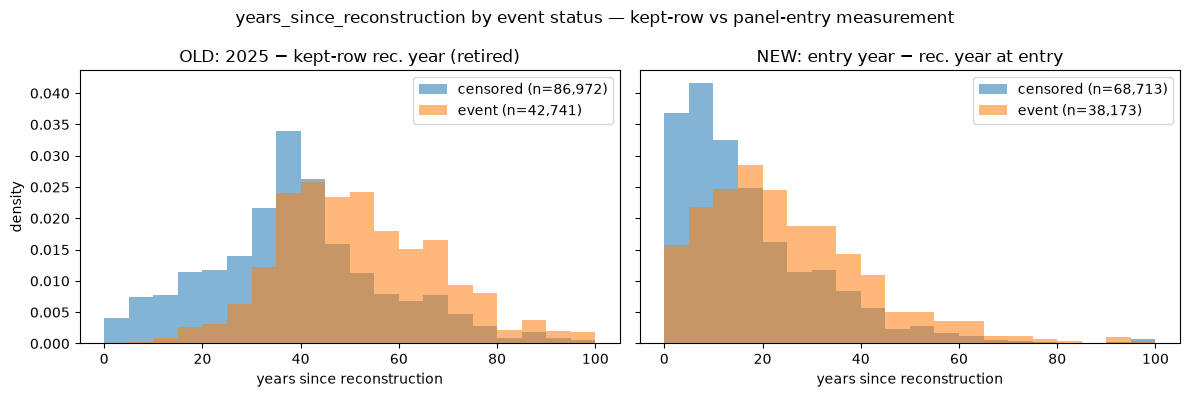

{
  "old_kept_row_ref_anchor": {
    "event": {
      "n_reconstructed": 42898,
      "share_rec_ge_2010": 0.0097,
      "median_ysr": 50.0
    },
    "censored": {
      "n_reconstructed": 86977,
      "share_rec_ge_2010": 0.1083,
      "median_ysr": 38.0
    }
  },
  "new_entry_row": {
    "event": {
      "n_reconstructed": 38278,
      "share_rec_ge_2010": 0.0056,
      "median_ysr": 21.0
    },
    "censored": {
      "n_reconstructed": 69067,
      "share_rec_ge_2010": 0.0169,
      "median_ysr": 13.0
    }
  },
  "note": "share_rec_ge_2010 must be ~equal across groups in the NEW variant; the OLD variant's gap is mechanical era leakage (kept-row truncation)."
}
wrote us_reconstruction_measurement.json


In [8]:
# ── Reconstruction covariate: before/after leakage check ─────────────────────
# OLD variant (retired): REF_YEAR - kept-row YEAR_RECONSTRUCTED_106 — the kept row is ~1996
# for events but ~2025 for censored, so it can't record post-event reconstructions and
# separates the groups mechanically (rec-since-2010 share ~1% events vs ~11% censored).
# NEW variant: entry_year - year_rec_at_entry, measured at each bridge's first observed row
# for both groups; any remaining difference is legitimate baseline signal.
import json
import matplotlib.pyplot as plt

a = pd.read_csv(OUT_A,
                usecols=["event", "YEAR_RECONSTRUCTED_106", "entry_year", "year_rec_at_entry"],
                low_memory=False)

def _clean_year(s):
    v = pd.to_numeric(s, errors="coerce")
    return v.mask((v < 1600) | (v > 2025))

old_yr = _clean_year(a["YEAR_RECONSTRUCTED_106"])        # kept-row value (era-truncated)
new_yr = _clean_year(a["year_rec_at_entry"])             # entry-row value (era-free)
old_ysr = (REF_YEAR - old_yr).mask(lambda v: (v < 0) | (v > 200))
new_ysr = (pd.to_numeric(a["entry_year"], errors="coerce") - new_yr).mask(lambda v: (v < 0) | (v > 200))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
bins = np.arange(0, 105, 5)
for ax, ysr, title in [(axes[0], old_ysr, f"OLD: {REF_YEAR} − kept-row rec. year (retired)"),
                       (axes[1], new_ysr, "NEW: entry year − rec. year at entry")]:
    for ev, lbl in [(0, "censored"), (1, "event")]:
        vals = ysr[a["event"] == ev].dropna()
        ax.hist(vals, bins=bins, density=True, alpha=0.55, label=f"{lbl} (n={len(vals):,})")
    ax.set_title(title)
    ax.set_xlabel("years since reconstruction")
    ax.legend()
axes[0].set_ylabel("density")
fig.suptitle("years_since_reconstruction by event status — kept-row vs panel-entry measurement")
fig.tight_layout()
plt.show()

def _summary(yr_col, ysr_col):
    out = {}
    for ev, lbl in [(1, "event"), (0, "censored")]:
        m = a["event"] == ev
        rec = yr_col[m].dropna()
        out[lbl] = {
            "n_reconstructed": int(len(rec)),
            "share_rec_ge_2010": round(float((rec >= 2010).mean()), 4) if len(rec) else None,
            "median_ysr": (round(float(ysr_col[m].median()), 1)
                           if ysr_col[m].notna().any() else None),
        }
    return out

recon = {"old_kept_row_ref_anchor": _summary(old_yr, old_ysr),
         "new_entry_row": _summary(new_yr, new_ysr),
         "note": ("share_rec_ge_2010 must be ~equal across groups in the NEW variant; "
                  "the OLD variant's gap is mechanical era leakage (kept-row truncation).")}
OUT_RECON_DIAG.write_text(json.dumps(recon, indent=2))
print(json.dumps(recon, indent=2))
print(f"wrote {OUT_RECON_DIAG}")


In [9]:
# ── Traffic covariates: kept-row vs entry-row leakage measurement ─────────────
# Same mechanism as the reconstruction year: the kept row is ~1996 for events vs ~2025 for
# censored, and ADT is re-measured over time (YEAR_ADT_030), so kept-row traffic values are
# recorded in systematically different eras by outcome class. Kept-row event-vs-censored
# gaps mix that era artifact with real cohort differences; the entry-row gap is the
# era-free (legitimate) part, and only the *_at_entry variants enter the models.
import json

TRAFFIC_PAIRS = [   # (kept-row column, entry-row column)
    ("ADT_029", "adt_at_entry"),
    ("TRAFFIC_LANES_ON_028A", "lanes_on_at_entry"),
    ("TRAFFIC_LANES_UND_028B", "lanes_und_at_entry"),
    ("PERCENT_ADT_TRUCK_109", "truck_pct_at_entry"),
]
usecols = ["event", "YEAR_ADT_030"] + [c for pair in TRAFFIC_PAIRS for c in pair]
a = pd.read_csv(OUT_A, usecols=usecols, low_memory=False)
ev, cn = a["event"] == 1, a["event"] == 0

def _stats(col, m):
    v = pd.to_numeric(a[col], errors="coerce")[m]
    ok = v.notna().any()
    return {"median": round(float(v.median()), 2) if ok else None,
            "mean": round(float(v.mean()), 2) if ok else None,
            "nan_share": round(float(v.isna().mean()), 4)}

ya = pd.to_numeric(a["YEAR_ADT_030"], errors="coerce")
ya = ya.mask((ya < 1950) | (ya > 2025))
audit = {
    "adt_measurement_year_kept_row": {
        "event_median": float(ya[ev].median()), "censored_median": float(ya[cn].median()),
        "note": "the era gap that makes kept-row traffic values a censoring fingerprint"},
    "covariates": {},
    "note": ("Models use only the *_at_entry variants; kept-row ADT_029 / lane counts / "
             "truck share are dropped in the encoding cell. Model-level inflation from the "
             "kept-row variants is measured in leakage_ablation_national.ipynb."),
}
for kept, entry in TRAFFIC_PAIRS:
    audit["covariates"][kept] = {
        "kept_row":  {"event": _stats(kept, ev),  "censored": _stats(kept, cn)},
        "entry_row": {"event": _stats(entry, ev), "censored": _stats(entry, cn)},
    }

print(f"ADT measurement year (kept row) median: event "
      f"{audit['adt_measurement_year_kept_row']['event_median']:.0f}, censored "
      f"{audit['adt_measurement_year_kept_row']['censored_median']:.0f}")
print(f"{'covariate':<24} {'kept ev/cen':>18} {'entry ev/cen':>18}")
for kept, entry in TRAFFIC_PAIRS:
    c = audit["covariates"][kept]
    k = f"{c['kept_row']['event']['median']} / {c['kept_row']['censored']['median']}"
    e = f"{c['entry_row']['event']['median']} / {c['entry_row']['censored']['median']}"
    print(f"{kept:<24} {k:>18} {e:>18}")
OUT_TRAFFIC_DIAG.write_text(json.dumps(audit, indent=2))
print(f"wrote {OUT_TRAFFIC_DIAG}")


ADT measurement year (kept row) median: event 1992, censored 2011
covariate                       kept ev/cen       entry ev/cen
ADT_029                       225.0 / 850.0      200.0 / 650.0
TRAFFIC_LANES_ON_028A             2.0 / 2.0          2.0 / 2.0
TRAFFIC_LANES_UND_028B            0.0 / 0.0          0.0 / 0.0
PERCENT_ADT_TRUCK_109             6.0 / 6.0          6.0 / 6.0
wrote us_traffic_leakage_measurement.json


In [10]:
# ── Verification ───────────────────────────────────────────────────────────────
a = pd.read_csv(OUT_A, dtype={"STRUCTURE_NUMBER_008": str, "STATE_FIPS": str}, low_memory=False)
clean = pd.read_csv(OUT_CLEAN, dtype={"STRUCTURE_NUMBER_008": str, "STATE_FIPS": str}, low_memory=False)

print("1. ROW COUNTS")
print(f"   bridges (Option A, culverts excluded): {len(a):,}   clean: {len(clean):,}   cols: {clean.shape[1]}")
print(f"   national event rate: {a['event'].mean()*100:.1f}%  ({int(a['event'].sum()):,} events)")

print("\n2. MA REPRODUCTION (FIPS 25) — counts now EXCLUDE culverts, so they sit below the")
print("   standalone MA model's ~19,956 bridges / ~3,989 events (which included culverts)")
ma = a[a["STATE_FIPS"] == "25"]
print(f"   MA bridges: {len(ma):,}   MA events: {int(ma['event'].sum()):,}   "
      f"rate: {ma['event'].mean()*100:.1f}%")

print("\n3. MERGE INTEGRITY")
miss_clim = a["freeze_thaw_cycles"].isna().mean() * 100
miss_coast = a["dist_to_coast_km"].isna().mean() * 100
imp = a["location_imputed"]
print(f"   NaN climate: {miss_clim:.2f}%   NaN coastal: {miss_coast:.2f}%   "
      f"location_imputed: {imp.mean()*100:.1f}%")
# Coverage: cell_map/coastal use the first valid coordinate from any survey year; the ~8%
# with none are imputed to the county centroid (location_imputed=1). Residual climate NaN =
# grid cells absent from the Daymet table (water / interior-AK).
c_meas = a.loc[imp == 0, "freeze_thaw_cycles"].isna().mean() * 100
c_imp  = a.loc[imp == 1, "freeze_thaw_cycles"].isna().mean() * 100
print(f"   climate NaN by group: measured {c_meas:.1f}%   imputed {c_imp:.1f}%   (coastal fully covered)")

print("\n4. NO LEAKAGE (must all be False)")
leak = ["DECK_COND_058","SUPERSTRUCTURE_COND_059","SUBSTRUCTURE_COND_060",
        "CHANNEL_COND_061","CULVERT_COND_062","BRIDGE_CONDITION","LOWEST_RATING",
        "OPEN_CLOSED_POSTED_041"]
print("   " + ", ".join(f"{c}={c in clean.columns}" for c in leak))

print("\n5. ENCODING SANITY")
print(f"   STATE_* dummies: {sum(c.startswith('STATE_') for c in clean.columns)}   "
      f"COUNTY_* dummies: {sum(c.startswith('COUNTY_') for c in clean.columns)} (want 0)")
print(f"   ever_reconstructed present: {'ever_reconstructed' in clean.columns}   "
      f"maintenance-history absent: {'had_maintenance' not in clean.columns}   "
      f"location_imputed present: {'location_imputed' in clean.columns}")

print("\n6. CULVERT EXCLUSION + ENTRY-ROW RECONSTRUCTION (this revision's contracts)")
n_culv_left = int((pd.to_numeric(a["STRUCTURE_TYPE_043B"], errors="coerce") == CULVERT_CODE).sum())
n_alln_left = int((a[["DECK_COND_058","SUPERSTRUCTURE_COND_059","SUBSTRUCTURE_COND_060"]] == 10)
                  .all(axis=1).sum())
era_cols_in_clean = {"entry_year", "year_rec_at_entry", "YEAR_RECONSTRUCTED_106",
                     "ADT_029", "TRAFFIC_LANES_ON_028A", "TRAFFIC_LANES_UND_028B",
                     "PERCENT_ADT_TRUCK_109", "YEAR_ADT_030"} & set(clean.columns)
print(f"   culvert rows left: {n_culv_left} (want 0)   all-'N' rows left: {n_alln_left} (want 0)")
print(f"   STRUCTURE_TYPE_043B_19 dummy in clean: {'STRUCTURE_TYPE_043B_19' in clean.columns} (want False)")
print(f"   era-carrier columns in clean: {era_cols_in_clean or 'none'} (want none)")
print(f"   entry columns present in data_a: "
      f"{ {'entry_year','year_rec_at_entry'} <= set(a.columns) } (want True — diagnostics need them)")
assert n_culv_left == 0 and n_alln_left == 0
assert "STRUCTURE_TYPE_043B_19" not in clean.columns
assert not era_cols_in_clean
entry_traffic = ["adt_at_entry", "lanes_on_at_entry", "lanes_und_at_entry", "truck_pct_at_entry"]
print(f"   entry-anchored traffic in clean: {set(entry_traffic) <= set(clean.columns)} (want True)   "
      f"adt_at_entry NaN: {pd.to_numeric(clean['adt_at_entry'], errors='coerce').isna().mean()*100:.1f}%")
assert {"entry_year", "year_rec_at_entry"} <= set(a.columns)
assert set(entry_traffic) <= set(a.columns) and set(entry_traffic) <= set(clean.columns)

print("\n7. PARAMETRIC MATRIX (drop_first variant)")
# Header-only + two-column reads keep this cheap; the full parametric file is ~1 GB.
param_cols_check = pd.read_csv(OUT_PARAM, nrows=0).columns
param_rows = len(pd.read_csv(OUT_PARAM, usecols=["STATE_FIPS"], dtype=str))
dropped = clean.columns.difference(param_cols_check)
extra   = param_cols_check.difference(clean.columns)
only_dummies = all(clean[c].dropna().isin([0, 1]).all() for c in dropped)
print(f"   rows: {param_rows:,} (clean: {len(clean):,} — must match)   "
      f"cols: {len(param_cols_check)} = {clean.shape[1]} - {len(dropped)} reference dummies")
print(f"   no columns beyond clean's: {len(extra) == 0}   "
      f"every dropped column is a 0/1 dummy: {only_dummies}")
print("   dropped:", ", ".join(sorted(dropped)))
assert param_rows == len(clean) and len(extra) == 0 and only_dummies

1. ROW COUNTS
   bridges (Option A, culverts excluded): 973,906   clean: 973,905   cols: 260
   national event rate: 29.3%  (285,082 events)

2. MA REPRODUCTION (FIPS 25) — counts now EXCLUDE culverts, so they sit below the
   standalone MA model's ~19,956 bridges / ~3,989 events (which included culverts)
   MA bridges: 18,893   MA events: 3,988   rate: 21.1%

3. MERGE INTEGRITY
   NaN climate: 1.14%   NaN coastal: 0.00%   location_imputed: 8.2%
   climate NaN by group: measured 0.4%   imputed 9.6%   (coastal fully covered)

4. NO LEAKAGE (must all be False)
   DECK_COND_058=False, SUPERSTRUCTURE_COND_059=False, SUBSTRUCTURE_COND_060=False, CHANNEL_COND_061=False, CULVERT_COND_062=False, BRIDGE_CONDITION=False, LOWEST_RATING=False, OPEN_CLOSED_POSTED_041=False

5. ENCODING SANITY
   STATE_* dummies: 52   COUNTY_* dummies: 0 (want 0)
   ever_reconstructed present: True   maintenance-history absent: True   location_imputed present: True

6. CULVERT EXCLUSION + ENTRY-ROW RECONSTRUCTION (t

   rows: 973,905 (clean: 973,905 — must match)   cols: 243 = 260 - 17 reference dummies
   no columns beyond clean's: True   every dropped column is a 0/1 dummy: True
   dropped: DECK_PROTECTION_0, DECK_TYPE_1, HISTORY_1, MAINTENANCE_1, MEDIAN_CODE_033_0, MEMBRANE_TYPE_0, PIER_PROTECTION_111_1, ROAD_CLASS_Collector, SERVICE_ON_042A_0, SERVICE_UND_042B_0, STATE_01, STRAHNET_HIGHWAY_100_0, STRUCTURE_KIND_043A_0, STRUCTURE_TYPE_043B_0, SURFACE_TYPE_0, TOLL_020_1, TRAFFIC_DIRECTION_102_0
